In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os

print('Libraries imported successfully!')

Libraries imported successfully!


In [10]:
DATA_PATH = 'C:/Users/Saurabh yadav/Documents/SaaS Growth Intelligence Platform/data_set/'

accounts      = pd.read_csv(DATA_PATH + 'ravenstack_accounts.csv')
subscriptions = pd.read_csv(DATA_PATH + 'ravenstack_subscriptions.csv')
churn         = pd.read_csv(DATA_PATH + 'ravenstack_churn_events.csv')
feature_usage = pd.read_csv(DATA_PATH + 'ravenstack_feature_usage.csv')
support       = pd.read_csv(DATA_PATH + 'ravenstack_support_tickets.csv')

print('All files loaded!')
print('accounts:     ', accounts.shape)
print('subscriptions:', subscriptions.shape)
print('churn:        ', churn.shape)
print('feature_usage:', feature_usage.shape)
print('support:      ', support.shape)

All files loaded!
accounts:      (500, 10)
subscriptions: (5000, 14)
churn:         (600, 9)
feature_usage: (25000, 8)
support:       (2000, 9)


In [11]:
tables = {
    'accounts': accounts,
    'subscriptions': subscriptions,
    'churn': churn,
    'feature_usage': feature_usage,
    'support': support
}

for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(name.upper())
        for col, count in missing.items():
            pct = round(count / len(df) * 100, 1)
            print('  ', col, ':', count, 'missing (', pct, '%)')
    else:
        print(name.upper(), ': No missing values')

ACCOUNTS : No missing values
SUBSCRIPTIONS
   end_date : 4514 missing ( 90.3 %)
CHURN
   feedback_text : 148 missing ( 24.7 %)
FEATURE_USAGE : No missing values
SUPPORT
   satisfaction_score : 825 missing ( 41.2 %)


In [12]:
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
accounts['is_trial']    = accounts['is_trial'].astype(bool)
accounts['churn_flag']  = accounts['churn_flag'].astype(bool)
print('accounts cleaned')

subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date']   = pd.to_datetime(subscriptions['end_date'])
subscriptions['is_active']  = subscriptions['end_date'].isna()
subscriptions['duration_days'] = (
    subscriptions['end_date'] - subscriptions['start_date']
).dt.days.fillna(0).astype(int)
print('subscriptions cleaned')

churn['churn_date']        = pd.to_datetime(churn['churn_date'])
churn['feedback_text']     = churn['feedback_text'].fillna('No feedback')
churn['refund_amount_usd'] = churn['refund_amount_usd'].round(2)
print('churn_events cleaned')

feature_usage['usage_date']          = pd.to_datetime(feature_usage['usage_date'])
feature_usage['usage_duration_mins'] = (feature_usage['usage_duration_secs'] / 60).round(2)
print('feature_usage cleaned')

support['submitted_at']       = pd.to_datetime(support['submitted_at'])
support['closed_at']          = pd.to_datetime(support['closed_at'])
support['satisfaction_score'] = support['satisfaction_score'].fillna(
    support['satisfaction_score'].median()).round(1)

def resolution_category(hours):
    if hours <= 4:
        return 'Fast under 4h'
    elif hours <= 24:
        return 'Standard 4 to 24h'
    else:
        return 'Slow over 24h'

support['resolution_category'] = support['resolution_time_hours'].apply(resolution_category)
print('support_tickets cleaned')

accounts cleaned
subscriptions cleaned
churn_events cleaned
feature_usage cleaned
support_tickets cleaned


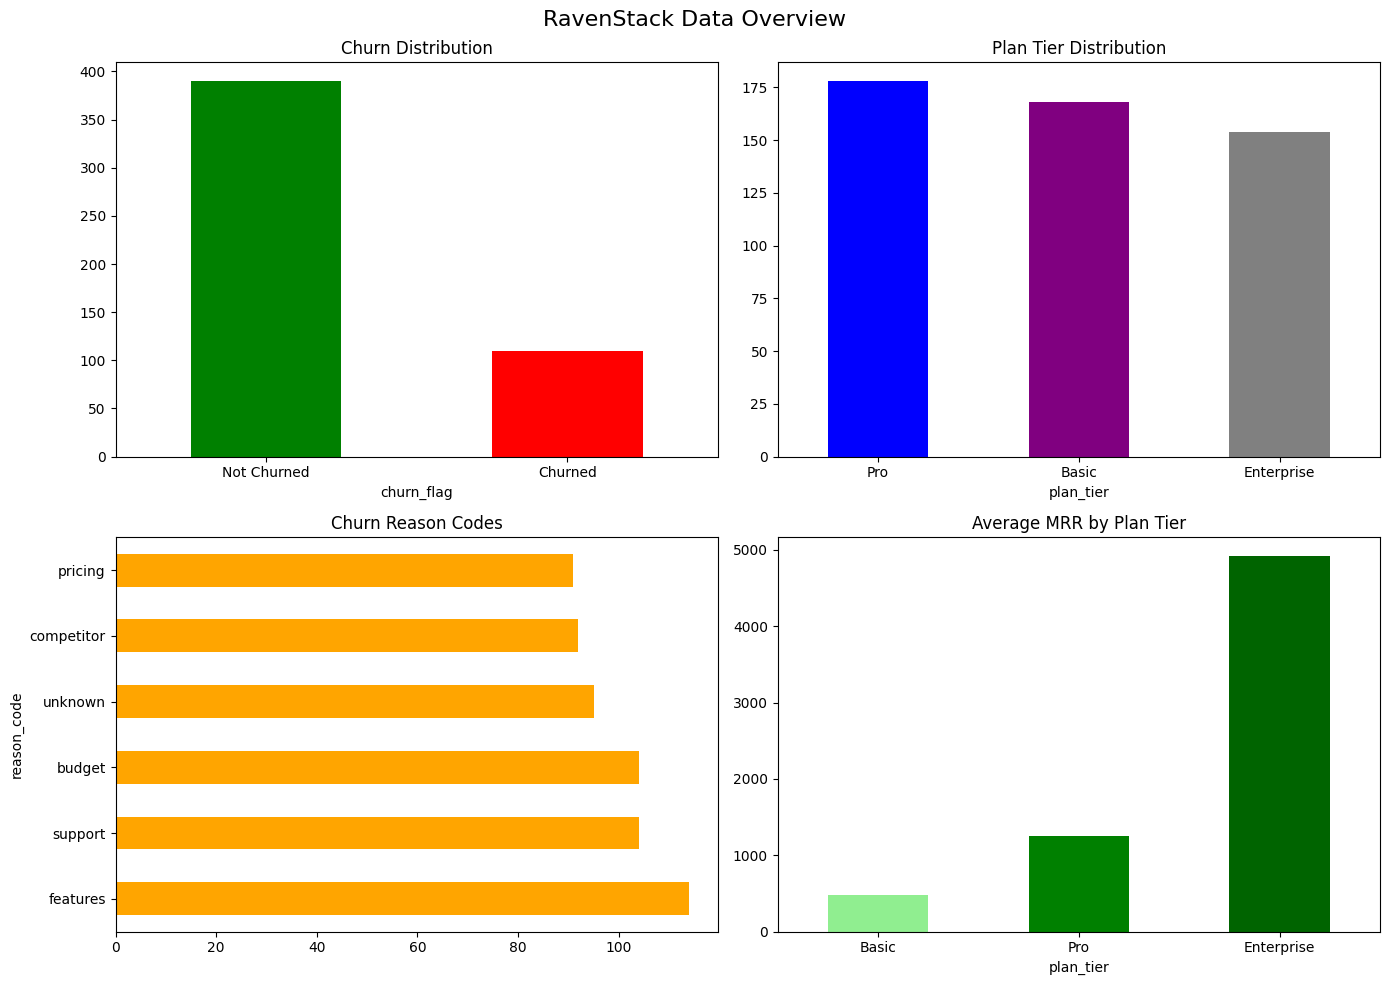

Charts done


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RavenStack Data Overview', fontsize=16)

accounts['churn_flag'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['green','red'], edgecolor='none')
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xticklabels(['Not Churned','Churned'], rotation=0)

accounts['plan_tier'].value_counts().plot(
    kind='bar', ax=axes[0,1], color=['blue','purple','gray'], edgecolor='none')
axes[0,1].set_title('Plan Tier Distribution')
axes[0,1].set_xticklabels(accounts['plan_tier'].value_counts().index, rotation=0)

churn['reason_code'].value_counts().plot(
    kind='barh', ax=axes[1,0], color='orange', edgecolor='none')
axes[1,0].set_title('Churn Reason Codes')

subscriptions.groupby('plan_tier')['mrr_amount'].mean().sort_values().plot(
    kind='bar', ax=axes[1,1], color=['lightgreen','green','darkgreen'], edgecolor='none')
axes[1,1].set_title('Average MRR by Plan Tier')
axes[1,1].set_xticklabels(
    subscriptions.groupby('plan_tier')['mrr_amount'].mean().sort_values().index, rotation=0)

plt.tight_layout()
plt.show()
print('Charts done')

In [15]:
import os

DB_FOLDER = 'C:/Users/Saurabh yadav/Documents/SaaS Growth Intelligence Platform/database'
DB_PATH   = DB_FOLDER + '/saas_data.db'

os.makedirs(DB_FOLDER, exist_ok=True)
print('Database folder ready')

engine = create_engine('sqlite:///' + DB_PATH)

accounts.to_sql('accounts',           engine, if_exists='replace', index=False)
subscriptions.to_sql('subscriptions', engine, if_exists='replace', index=False)
churn.to_sql('churn_events',          engine, if_exists='replace', index=False)
feature_usage.to_sql('feature_usage', engine, if_exists='replace', index=False)
support.to_sql('support_tickets',     engine, if_exists='replace', index=False)

print('All tables saved to database')

Database folder ready
All tables saved to database


In [16]:
import sqlite3

conn = sqlite3.connect(DB_PATH)
print('TABLES IN DATABASE:')
for table in ['accounts','subscriptions','churn_events','feature_usage','support_tickets']:
    count = pd.read_sql('SELECT COUNT(*) as rows FROM ' + table, conn)
    print(' ', table, ':', count['rows'].values[0], 'rows')

conn.close()
print('Phase 1 Complete! Database is ready.')

TABLES IN DATABASE:
  accounts : 500 rows
  subscriptions : 5000 rows
  churn_events : 600 rows
  feature_usage : 25000 rows
  support_tickets : 2000 rows
Phase 1 Complete! Database is ready.
